   # Práctica de IA + fototrampeo: MegaDetector


D. Velasco-Montero, 2026

En esta sesión de trabajo con Jupyter veremos la implementación en Python de **[MegaDetector](https://github.com/microsoft/MegaDetector)** y lo aplicaremos a un conjunto de imágenes del dataset [Snapshot Serengeti](https://lila.science/datasets/snapshot-serengeti/).

> Imágenes &rarr; MegaDetector &rarr; Bounding boxes y Confianza &rarr; Revisión manual

Usaremos las siguientes librerías de Python:
* [Numpy](https://numpy.org/)
* [Matplotlib](https://matplotlib.org/)
* [Pillow](https://pillow.readthedocs.io/en/stable/)
* [Pandas](https://pandas.pydata.org/)

## 0. Instalar y cargar librerías en Python

Si no tenemos instaladas las librerías, habría que ejecutar lo siguiente:

In [49]:
!pip install matplotlib Pillow numpy
!pip install PytorchWildlife

Cargamos las librerías:

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image

import pandas as pd
import numpy as np

## 1. Objetivos


En esta práctica aprenderemos a:

- Ejecutar MegaDetector sobre imágenes de cámaras trampa.
- Interpretar las detecciones.
- Visualizar los resultados.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
!pwd
!ls /content/drive/MyDrive/SS_example_images/

Mounted at /content/drive
/content
S1_B05_R2_PICT0011.JPG	S1_L12_R1_PICT0192.JPG	S2_R08_R2_IMAG0011.JPG
S1_F12_R1_PICT1294.JPG	S2_E08_R2_IMAG0950.JPG
S1_L10_R1_PICT0042.JPG	S2_F01_R3_IMAG0450.JPG


Observa estas cinco imágenes.

¿Cuáles contienen animales? ¿ Dónde están?

In [4]:
# Lista de imágenes
folder = "/content/drive/MyDrive/SS_example_images/"

imagenes = sorted(Path(folder).glob("*.JPG"))
print(f"{len(imagenes)} imágenes encontradas.")

7 imágenes encontradas.


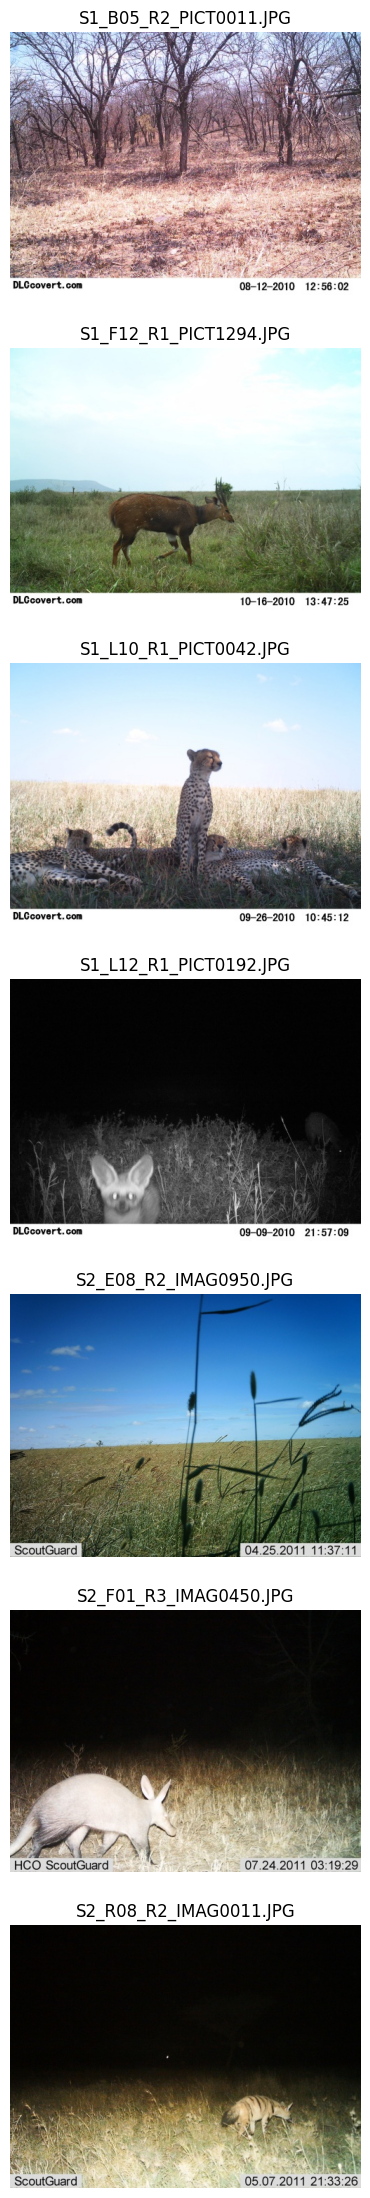

In [5]:
# Mostrarlas
fig, ax = plt.subplots(len(imagenes),1,
                       figsize=(8,4*len(imagenes)))

if len(imagenes)==1:
    ax=[ax]

for i,imagen in enumerate(imagenes):

    ax[i].imshow(Image.open(imagen))
    ax[i].set_title(imagen.name)
    ax[i].axis("off")

## 2. Ejecutar MegaDetector

Primero ecargamos el modelo detector. Es una red neuronal convolucional de detección de objetos entrenada con individuos de animales. El objetivo del modelo es determinar la localización (bounding box) del individuo y clasificarlo en una de las 3 siguientes categorías:
 - 0: animal
 - 1: person
 - 2: vehicle

 Notar que MegaDetector **no** clasifica el individuo detectado en función de su especie, simplemente lo identifica. Para ello, se suelen usar modelos de clasificación posteriormente sobre las imágenes con detecciones.

In [8]:
# Documentación en:
# https://github.com/microsoft/Pytorch-Wildlife/
# https://github.com/microsoft/MegaDetector
# https://github.com/microsoft/Pytorch-Wildlife/blob/main/demo/image_demo.py

from PytorchWildlife.models import detection as pw_detection

# Detection — weights download automatically
detection_model = pw_detection.MegaDetectorV6(version="MDV6-yolov10-c")
detection_result = detection_model.single_image_detection(str(imagenes[0]))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv10n summary (fused): 101 layers, 2,265,753 parameters, 0 gradients, 6.5 GFLOPs

0: 1280x1280 (no detections), 975.5ms
Speed: 92.4ms preprocess, 975.5ms inference, 3.2ms postprocess per image at shape (1, 3, 1280, 1280)


Ahora usamos las funciones de la librería para ejecutar el modelo sobre un conjunto (batch) de imágenes (las contenidas en la carpeta especificada):

In [9]:
resultados = detection_model.batch_image_detection(folder)

  0%|          | 0/1 [00:00<?, ?it/s]


0: 1280x1280 2 animals, 1216.3ms
1: 1280x1280 1 animal, 1216.3ms
2: 1280x1280 6 animals, 1216.3ms
3: 1280x1280 (no detections), 1216.3ms
4: 1280x1280 (no detections), 1216.3ms
5: 1280x1280 1 animal, 1216.3ms
6: 1280x1280 1 animal, 1216.3ms
Speed: 58.4ms preprocess, 1216.3ms inference, 0.2ms postprocess per image at shape (7, 3, 1280, 1280)


100%|██████████| 1/1 [00:10<00:00, 10.18s/it]


Podemos inspeccionar cómo son los resultados. Tenemos una lista de diccionarios, donde cada elemento de la lista contiene:
- el identificador de la imagen
- las detecciones realizadas
- las etiquetas correspondientes a esas detecciones (animal, person, vehicle)
- las coordenadas normalizadas de las detecciones

Si vemos por ejemplo cómo son las detecciones, éstas incluyen:
- la posición xy de cada bounding box
- las confianzas asociadas
- las clases asociadas (0: animal, 1: person, 2: vehicle)

In [19]:
for k in resultados[0]:
  print(f"-> {k}, con valor: {resultados[0][k]}")

-> img_id, con valor: /content/drive/MyDrive/SS_example_images/S1_L12_R1_PICT0192.JPG
-> detections, con valor: Detections(xyxy=array([[     113.97,      249.07,      215.27,      349.99],
       [     419.11,      189.89,      486.12,      256.69]], dtype=float32), mask=None, confidence=array([    0.95071,     0.89711], dtype=float32), class_id=array([0, 0]), tracker_id=None, data={})
-> labels, con valor: ['animal 0.95', 'animal 0.90']
-> normalized_coords, con valor: [[np.float32(0.22793981), np.float32(0.664186), np.float32(0.43053392), np.float32(0.933308)], [np.float32(0.8382236), np.float32(0.5063607), np.float32(0.97224355), np.float32(0.6845041)]]


Podemos usar otras funciones de la librería para guardar directamente los resultados como una imagen, incluyendo las bounding boxes detectadas:

In [20]:
from PytorchWildlife import utils as pw_utils
help(pw_utils.save_detection_images)

Help on function save_detection_images in module PytorchWildlife.utils.post_process:

save_detection_images(results, output_dir, input_dir=None, overwrite=False)
    Save detected images with bounding boxes and labels annotated.

    Args:
        results (list or dict):
            Detection results containing image ID, detections, and labels.
        output_dir (str):
            Directory to save the annotated images.
        input_dir (str):
            Directory containing the input images. Default to None.
        overwrite (bool):
            Whether overwriting existing image folders. Default to False.



In [23]:
from PytorchWildlife import utils as pw_utils
pw_utils.save_detection_images(resultados, "demo_output", overwrite=False)

Si las mostramos, tenemos:

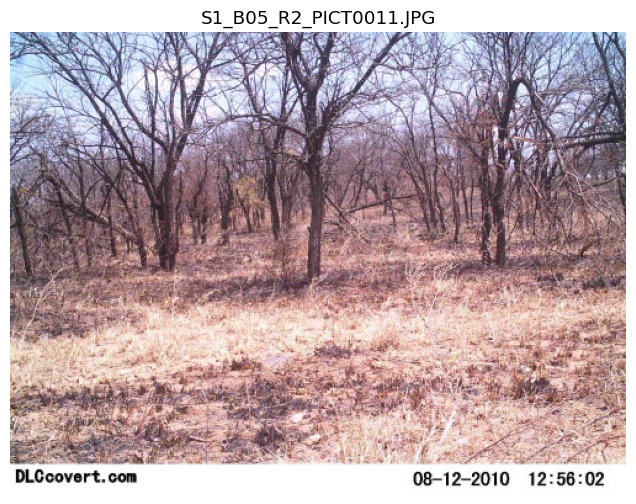

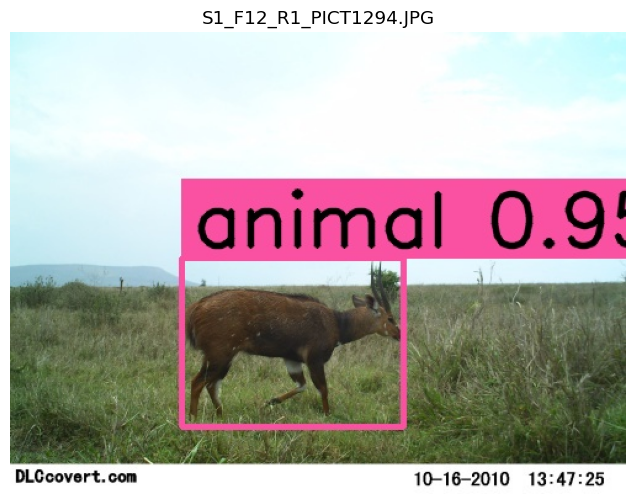

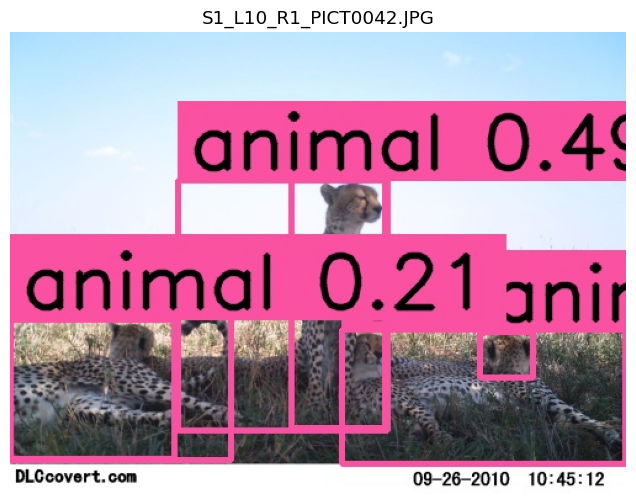

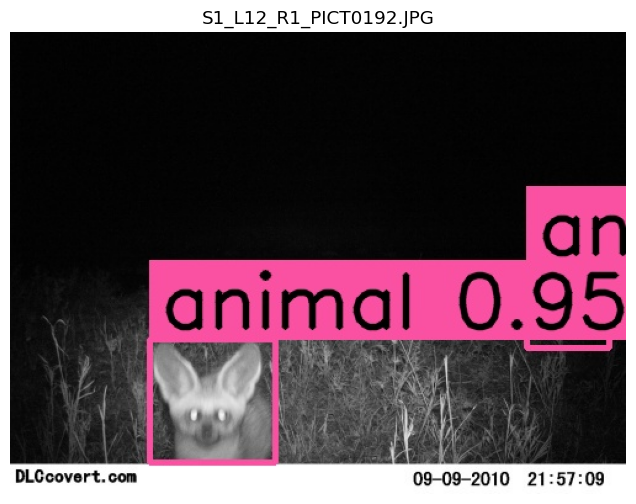

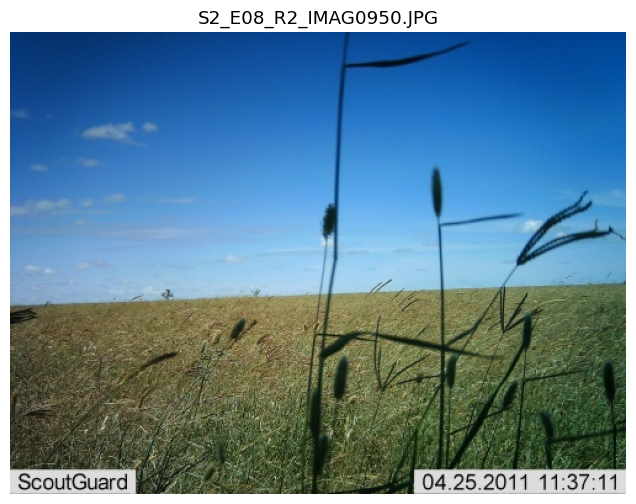

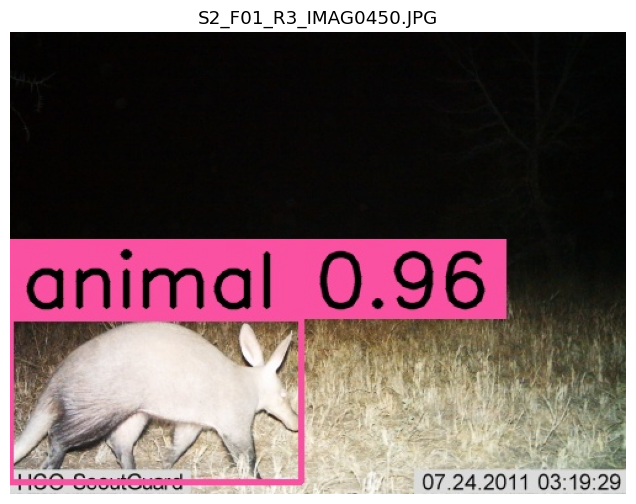

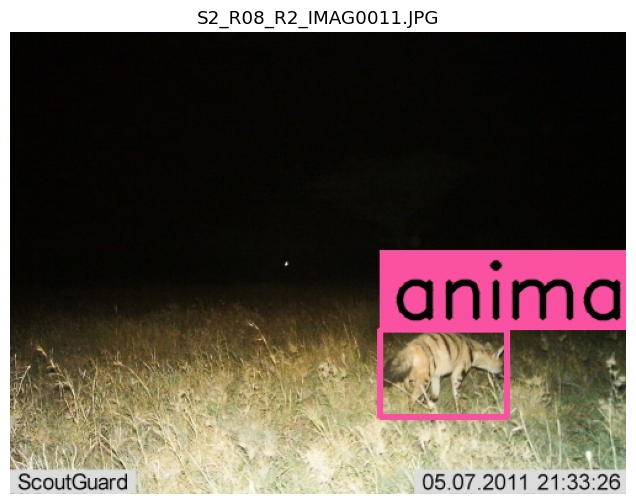

In [24]:
%matplotlib inline

from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

carpeta = Path("demo_output")

for archivo in sorted(carpeta.glob("*.JPG")):
    img = Image.open(archivo)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(archivo.name)
    plt.axis("off")
    plt.show()

También podemos guardar las images con "puntos" en lugar de bounding boxes, o guardar simplemente los recortes. Por ejemplo:

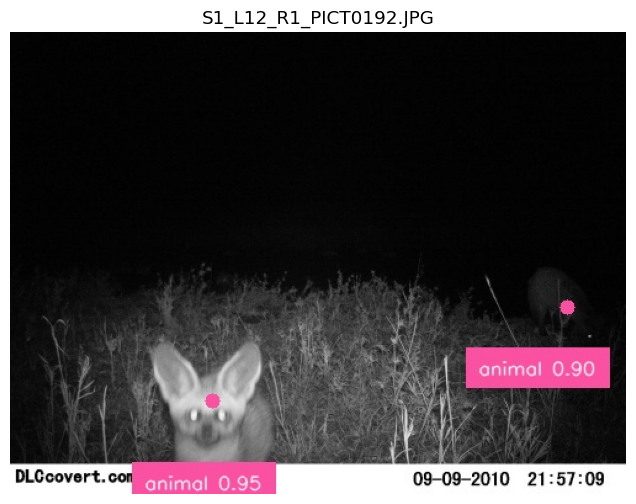

[PosixPath('demo_output/S1_L12_R1_PICT0192.JPG')]


In [37]:
# Guardar "dots"
pw_utils.save_detection_images_dots(resultados[0], "demo_output", overwrite=True)

# Representar:
for archivo in sorted(carpeta.glob("*.JPG")):
    img = Image.open(archivo)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(archivo.name)
    plt.axis("off")
    plt.show()

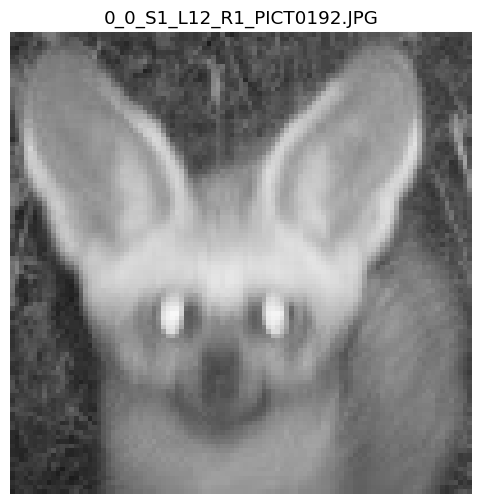

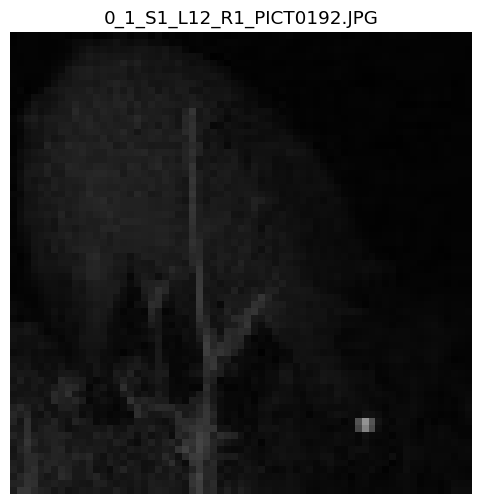

In [38]:
# Guardar "dots"
pw_utils.save_crop_images(resultados[0], "demo_output", overwrite=True)

# Representar:
for archivo in sorted(carpeta.glob("*.JPG")):
    img = Image.open(archivo)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(archivo.name)
    plt.axis("off")
    plt.show()

## Alternativa

Podemos usar la Demo de MegaDetector online en [Hugging Face](https://huggingface.co/spaces/ai-for-good-lab/pytorch-wildlife)